# Neural Network Classifier Pipeline
This notebook demonstrates the pipeline for training, predicting, and evaluating the provided Neural Network, including calculating AUC and significance metrics.
The dataset is imported directly from the HiggsML package.

In [1]:
!pip install HiggsML

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [2]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.run_functions_eagerly(False)

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


class NeuralNetwork:

    def __init__(self, n_features=None):
        self.model  = None
        self.scaler = StandardScaler()

        self._predictions  = None
        self._test_labels  = None
        self._test_weights = None

        if n_features is not None:
            self._initialize_model(n_features)

    def _initialize_model(self, n_features):
        """Initialize the model architecture."""
        self.model = Sequential([
            Dense(256, input_dim=n_features, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(256, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(64, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(1, activation="sigmoid"),
        ])

        self.model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=[AUC(name="auc")],
        )

    def fit(self, train_data, y_train, weights_train=None):
        """Train the model."""
        if self.model is None:
            raise ValueError(
                "Model is not initialized. Ensure `_initialize_model` is called or load a saved model."
            )

        X_train = self.scaler.fit_transform(train_data)

        callbacks = [
            EarlyStopping(
                monitor="val_auc", mode="max",
                patience=10, restore_best_weights=True, verbose=1,
            ),
            ReduceLROnPlateau(
                monitor="val_auc", mode="max",
                factor=0.5, patience=5, min_lr=1e-6, verbose=1,
            ),
        ]

        self.history = self.model.fit(
            X_train, y_train,
            sample_weight=weights_train,
            epochs=100,
            batch_size=512,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=2,
        )

    def predict(self, test_data, labels=None, weights=None):
        self._predictions = self.model.predict(
            self.scaler.transform(test_data), verbose=0
        ).ravel()

        if labels  is not None: self._test_labels  = np.asarray(labels)
        if weights is not None: self._test_weights = np.asarray(weights)

        return self._predictions

    def significance(self, test_labels=None, test_weights=None):
        if test_labels  is not None: self._test_labels  = np.asarray(test_labels)
        if test_weights is not None: self._test_weights = np.asarray(test_weights)

        if self._predictions is None:
            raise ValueError("No predictions found. Call predict() first.")
        if self._test_labels is None:
            raise ValueError(
                "True labels for test data are not available. Please provide them when calling predict()."
            )

        def __amsasimov(s_in, b_in):
            s = np.asarray(s_in, float)
            b = np.asarray(b_in, float)
            # Mask low-statistics region: b < 1 means the Poisson approximation
            # underlying AMS has broken down — results there are not meaningful.
            valid = (b >= 1.0) & (s >= 0)
            safe_b = np.where(valid, b, 1.0)
            safe_s = np.where(valid, s, 0.0)
            ams = np.sqrt(2 * ((safe_s + safe_b) * np.log(1 + safe_s / safe_b) - safe_s))
            ams = np.where(valid, ams, np.nan)
            if np.isscalar(s_in):
                return float(ams)
            else:
                return ams

        def __significance_vscore(y_true, y_score, sample_weight=None):
            if sample_weight is None:
                sample_weight = np.full(len(y_true), 1.0)
            else:
                sample_weight = np.asarray(sample_weight)
            bins = np.linspace(0, 1.0, 101)
            s_hist, _ = np.histogram(
                y_score[y_true == 1], bins=bins, weights=sample_weight[y_true == 1]
            )
            b_hist, _ = np.histogram(
                y_score[y_true == 0], bins=bins, weights=sample_weight[y_true == 0]
            )
            s_cumul = np.cumsum(s_hist[::-1])[::-1]
            b_cumul = np.cumsum(b_hist[::-1])[::-1]
            significance = __amsasimov(s_cumul, b_cumul)
            return significance

        vamsasimov_xgb = __significance_vscore(
            y_true=self._test_labels,
            y_score=self._predictions,
            sample_weight=self._test_weights,
        )

        plt.plot(np.linspace(0, 1.0, 100), vamsasimov_xgb, label="AMS Significance")
        plt.xlabel("Score")
        plt.ylabel("Significance")
        return float(np.nanmax(vamsasimov_xgb))

    def plot_learning_curves(self, weighted_test_auc=None):
        if not hasattr(self, "history"):
            raise ValueError("Model must be trained before plotting learning curves.")
        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax2 = ax1.twinx()

        l1, = ax1.plot(self.history.history["auc"],     color="tab:blue",   label="AUC (train)")
        # val_auc is computed on the internal validation split WITHOUT event weights
        # — it is optimistic relative to the weighted test AUC.
        l2, = ax2.plot(self.history.history["loss"],    color="tab:orange", label="Loss (train)")
        lines = [l1, l2]
        if "val_auc" in self.history.history:
            l3, = ax1.plot(self.history.history["val_auc"],  color="tab:blue",   linestyle="--", label="AUC (internal val, unweighted)")
            lines.append(l3)
        if "val_loss" in self.history.history:
            l4, = ax2.plot(self.history.history["val_loss"], color="tab:orange", linestyle="--", label="Loss (internal val, unweighted)")
            lines.append(l4)
        if weighted_test_auc is not None:
            l5 = ax1.axhline(weighted_test_auc, color="tab:green", linestyle=":", linewidth=1.5,
                             label=f"AUC (weighted test set) = {weighted_test_auc:.4f}")
            lines.append(l5)

        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("AUC",  color="tab:blue")
        ax2.set_ylabel("Loss", color="tab:orange")
        ax1.tick_params(axis="y", labelcolor="tab:blue")
        ax2.tick_params(axis="y", labelcolor="tab:orange")
        ax1.legend(lines, [l.get_label() for l in lines])
        ax1.grid(True)
        plt.title("Learning Curves")
        plt.tight_layout()
        plt.show()

    def plot_score_distribution(self, X_test, y_test):
        y_pred = self.predict(X_test)

        signal_scores = y_pred[y_test == 1]
        bkg_scores    = y_pred[y_test == 0]

        plt.figure(figsize=(8, 6))
        plt.hist(signal_scores, bins=50, alpha=0.5, label='Signal',     color='blue', density=True)
        plt.hist(bkg_scores,    bins=50, alpha=0.5, label='Background', color='red',  density=True)
        plt.title('Score Distribution (Signal vs Background)')
        plt.xlabel('Prediction Score')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self, path):
        """Save the trained model and scaler to the specified path."""
        os.makedirs(path, exist_ok=True)
        self.model.save(os.path.join(path, "model.keras"))
        joblib.dump(self.scaler, os.path.join(path, "scaler.pkl"))
        print(f"Model saved to {path}")

    def load_model(self, path):
        """Load the trained model and scaler from the specified path."""
        self.model  = load_model(os.path.join(path, "model.keras"))
        self.scaler = joblib.load(os.path.join(path, "scaler.pkl"))
        print(f"Model loaded from {path}")

### Load Physical Data
We load the dataset using the same split as the starting kit:
- **Test set**: first `test_size` rows, split by physics process (ztautau, diboson, ttbar, htautau).
- **Train set**: remaining rows, with balanced weights.

In [3]:
import pandas as pd
from HiggsML.datasets import download_dataset

dataset_name = "blackSwan_data"
print(f"Loading dataset: {dataset_name}")
data = download_dataset(dataset_name)

# --- Load train set (random sampling, intentionally non-deterministic) ---
data.load_train_set()
df_train = data.get_train_set()

feature_cols = [c for c in df_train.columns if c not in ("labels", "weights", "detailed_labels")]

X_train       = df_train[feature_cols].values
y_train       = df_train["labels"].values
weights_train = df_train["weights"].values

# --- Load test set (deterministic: always the same first test_size rows) ---
data.load_test_set()
test_set = data.get_test_set()   # dict: {"ztautau", "diboson", "ttbar", "htautau"}

signal_df = test_set["htautau"].copy()
signal_df["labels"] = 1

bkg_frames = []
for proc in ("ztautau", "diboson", "ttbar"):
    df = test_set[proc].copy()
    df["labels"] = 0
    bkg_frames.append(df)

df_test = pd.concat([signal_df] + bkg_frames, ignore_index=True)

X_test       = df_test[feature_cols].values
y_test       = df_test["labels"].values
weights_test = df_test["weights"].values

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape:  {X_test.shape}")

Loading dataset: blackSwan_data
Training data shape: (1400000, 28)
Testing data shape:  (600000, 28)


### Train the Model

In [4]:
nn = NeuralNetwork(n_features=X_train.shape[1])
print("Starting training...")
nn.fit(X_train, y_train, weights_train=weights_train)
print("Training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/100
2188/2188 - 24s - 11ms/step - auc: 0.7215 - loss: 0.0053 - val_auc: 0.8225 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 2/100
2188/2188 - 10s - 5ms/step - auc: 0.8119 - loss: 0.0025 - val_auc: 0.8384 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/100
2188/2188 - 11s - 5ms/step - auc: 0.8274 - loss: 0.0024 - val_auc: 0.8402 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
2188/2188 - 10s - 5ms/step - auc: 0.8341 - loss: 0.0023 - val_auc: 0.8433 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/100
2188/2188 - 9s - 4ms/step - auc: 0.8365 - loss: 0.0023 - val_auc: 0.8387 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/100
2188/2188 - 10s - 5ms/step - auc: 0.8385 - loss: 0.0023 - val_auc: 0.8412 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/100
2188/2188 - 10s - 4ms/step - auc: 0.8399 - loss: 0.0022 - val_auc: 0.8483 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
2188/2188 - 9s - 4ms/step - auc: 0.8412 - loss: 0.0022 - val_auc

### Test the Model and Evaluate Metrics (AUC & Significance)


ROC AUC Score: 0.8801


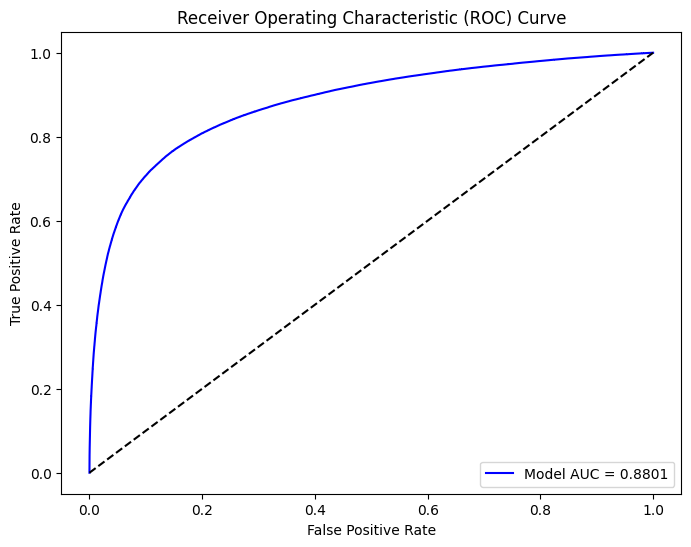

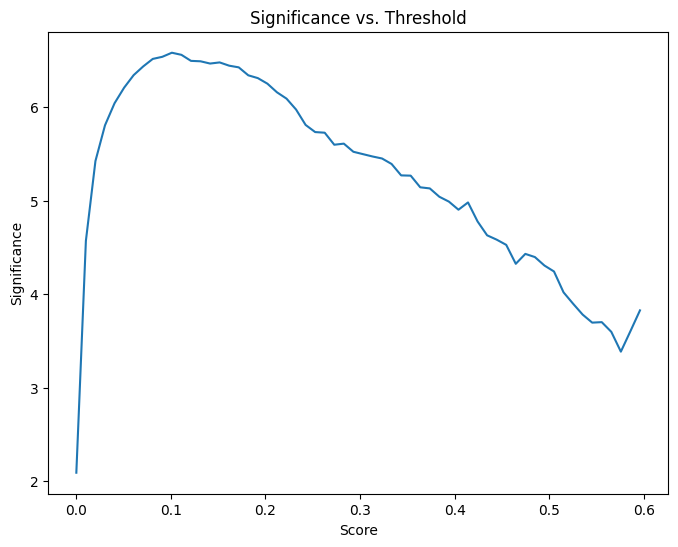

Max Significance: 6.5811

Plotting learning curves...


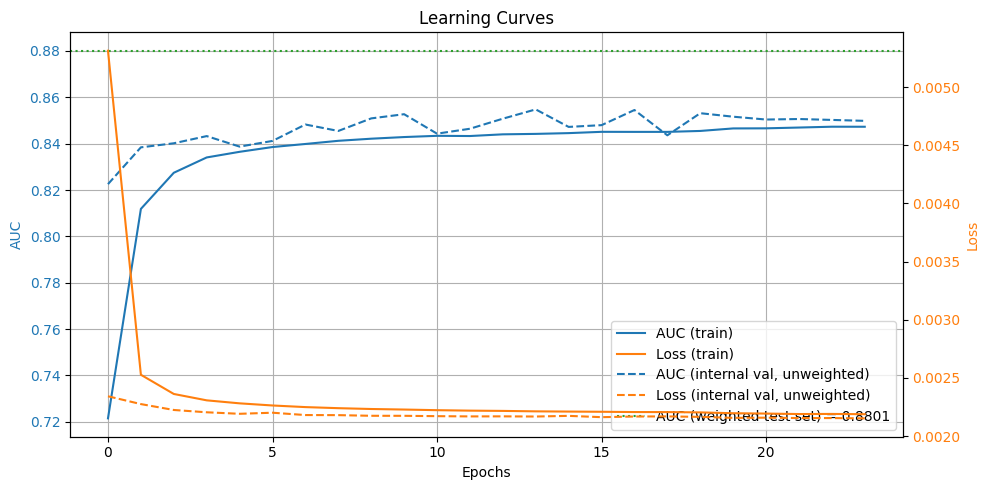


Plotting score distribution...


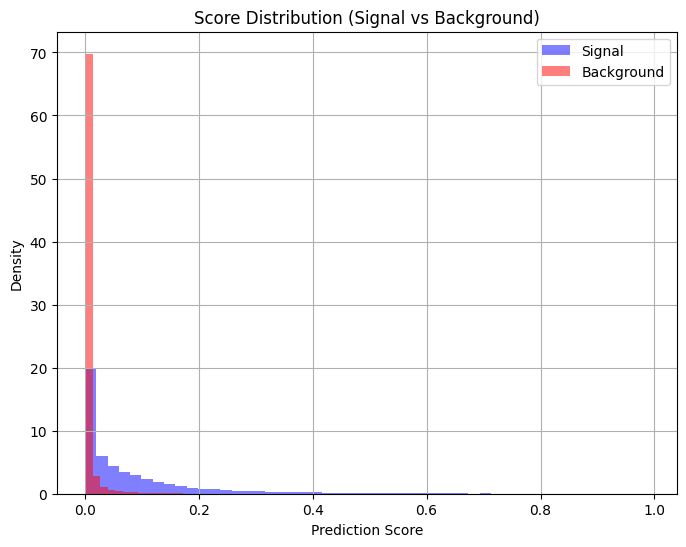

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict on the test set
predictions = nn.predict(X_test, labels=y_test, weights=weights_test)

# Calculate AUC
auc = roc_auc_score(y_test, predictions, sample_weight=weights_test)
print(f"\nROC AUC Score: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions, sample_weight=weights_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model AUC = {auc:.4f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Calculate and Plot Significance
plt.figure(figsize=(8, 6))
max_significance = nn.significance()
plt.title('Significance vs. Threshold')
plt.show()

print(f"Max Significance: {max_significance:.4f}")

# Plot learning curves — pass weighted test AUC so it appears as a reference line
print("\nPlotting learning curves...")
nn.plot_learning_curves(weighted_test_auc=auc)

# Plot score distribution
print("\nPlotting score distribution...")
nn.plot_score_distribution(X_test, y_test)

### Multi-Model Training and Statistical Analysis
Train N_MOD independent models on the same architecture and compare their AUCs, learning curves, and significance scores.


=== Training model 1/10 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2188/2188 - 25s - 11ms/step - auc: 0.7207 - loss: 0.0053 - val_auc: 0.8239 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/100
2188/2188 - 10s - 5ms/step - auc: 0.8113 - loss: 0.0025 - val_auc: 0.8270 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/100
2188/2188 - 9s - 4ms/step - auc: 0.8261 - loss: 0.0024 - val_auc: 0.8420 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
2188/2188 - 10s - 5ms/step - auc: 0.8336 - loss: 0.0023 - val_auc: 0.8387 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/100
2188/2188 - 10s - 5ms/step - auc: 0.8362 - loss: 0.0023 - val_auc: 0.8435 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/100
2188/2188 - 9s - 4ms/step - auc: 0.8380 - loss: 0.0023 - val_auc: 0.8410 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/100
2188/2188 - 11s - 5ms/step - auc: 0.8398 - loss: 0.0023 - val_auc: 0.8408 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
2188/2188 - 10s - 5ms/step - auc: 0.8409 - loss: 0.0022 - val_auc: 0.8498 - val_loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2188/2188 - 23s - 11ms/step - auc: 0.7257 - loss: 0.0052 - val_auc: 0.8241 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/100
2188/2188 - 10s - 5ms/step - auc: 0.8129 - loss: 0.0025 - val_auc: 0.8328 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/100
2188/2188 - 10s - 5ms/step - auc: 0.8253 - loss: 0.0024 - val_auc: 0.8416 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
2188/2188 - 9s - 4ms/step - auc: 0.8333 - loss: 0.0023 - val_auc: 0.8396 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/100
2188/2188 - 10s - 4ms/step - auc: 0.8361 - loss: 0.0023 - val_auc: 0.8405 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/100
2188/2188 - 10s - 4ms/step - auc: 0.8383 - loss: 0.0023 - val_auc: 0.8393 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/100
2188/2188 - 10s - 4ms/step - auc: 0.8398 - loss: 0.0023 - val_auc: 0.8436 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
2188/2188 - 9s - 4ms/step - auc: 0.8408 - loss: 0.0022 - val_auc: 0.8452 - val_loss: 

...

Epoch 1/100
2188/2188 - 23s - 11ms/step - auc: 0.7264 - loss: 0.0052 - val_auc: 0.8242 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/100
2188/2188 - 10s - 4ms/step - auc: 0.8125 - loss: 0.0025 - val_auc: 0.8350 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/100
2188/2188 - 10s - 5ms/step - auc: 0.8232 - loss: 0.0024 - val_auc: 0.8376 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
2188/2188 - 9s - 4ms/step - auc: 0.8321 - loss: 0.0023 - val_auc: 0.8431 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/100
2188/2188 - 10s - 4ms/step - auc: 0.8363 - loss: 0.0023 - val_auc: 0.8461 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/100
2188/2188 - 10s - 4ms/step - auc: 0.8379 - loss: 0.0023 - val_auc: 0.8458 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/100
2188/2188 - 10s - 4ms/step - auc: 0.8399 - loss: 0.0023 - val_auc: 0.8429 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
2188/2188 - 9s - 4ms/step - auc: 0.8408 - loss: 0.0022 - val_auc: 0.8440 - val_loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2188/2188 - 24s - 11ms/step - auc: 0.7225 - loss: 0.0053 - val_auc: 0.8237 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/100
2188/2188 - 10s - 5ms/step - auc: 0.8141 - loss: 0.0025 - val_auc: 0.8357 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/100
2188/2188 - 10s - 5ms/step - auc: 0.8253 - loss: 0.0024 - val_auc: 0.8348 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
2188/2188 - 9s - 4ms/step - auc: 0.8332 - loss: 0.0023 - val_auc: 0.8342 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/100
2188/2188 - 10s - 5ms/step - auc: 0.8366 - loss: 0.0023 - val_auc: 0.8459 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/100
2188/2188 - 10s - 4ms/step - auc: 0.8382 - loss: 0.0023 - val_auc: 0.8475 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/100
2188/2188 - 10s - 4ms/step - auc: 0.8401 - loss: 0.0023 - val_auc: 0.8485 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
2188/2188 - 9s - 4ms/step - auc: 0.8408 - loss: 0.0022 - val_auc: 0.8466 - val_loss: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2188/2188 - 24s - 11ms/step - auc: 0.7207 - loss: 0.0053 - val_auc: 0.8268 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/100
2188/2188 - 10s - 4ms/step - auc: 0.8138 - loss: 0.0025 - val_auc: 0.8352 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/100
2188/2188 - 9s - 4ms/step - auc: 0.8268 - loss: 0.0024 - val_auc: 0.8416 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
2188/2188 - 10s - 4ms/step - auc: 0.8332 - loss: 0.0023 - val_auc: 0.8403 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/100
2188/2188 - 10s - 5ms/step - auc: 0.8363 - loss: 0.0023 - val_auc: 0.8403 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/100
2188/2188 - 9s - 4ms/step - auc: 0.8382 - loss: 0.0023 - val_auc: 0.8500 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/100
2188/2188 - 10s - 4ms/step - auc: 0.8399 - loss: 0.0023 - val_auc: 0.8477 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
2188/2188 - 10s - 4ms/step - auc: 0.8409 - loss: 0.0022 - val_auc: 0.8458 - val_loss: 

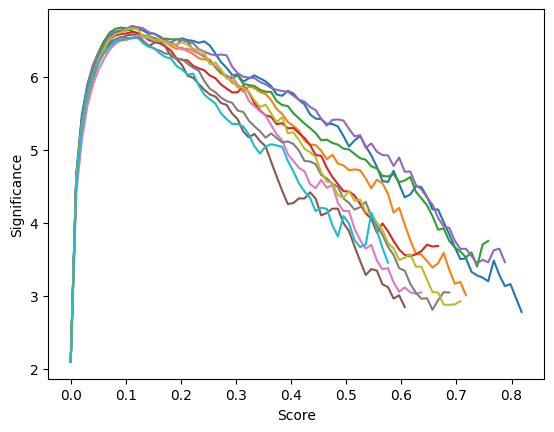

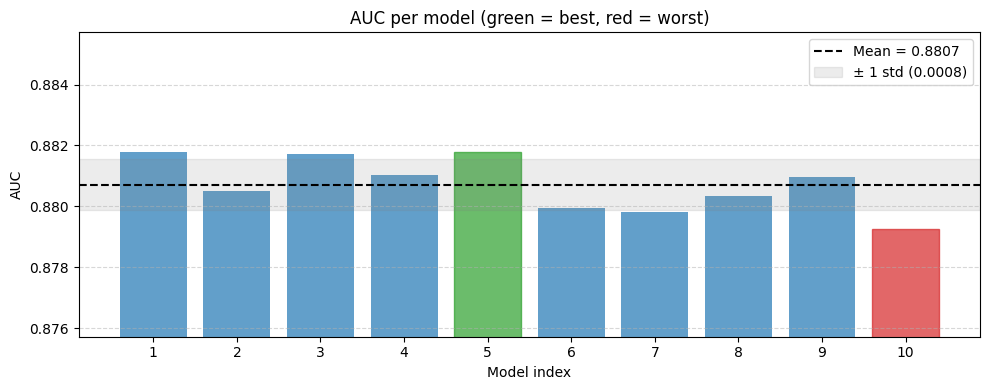

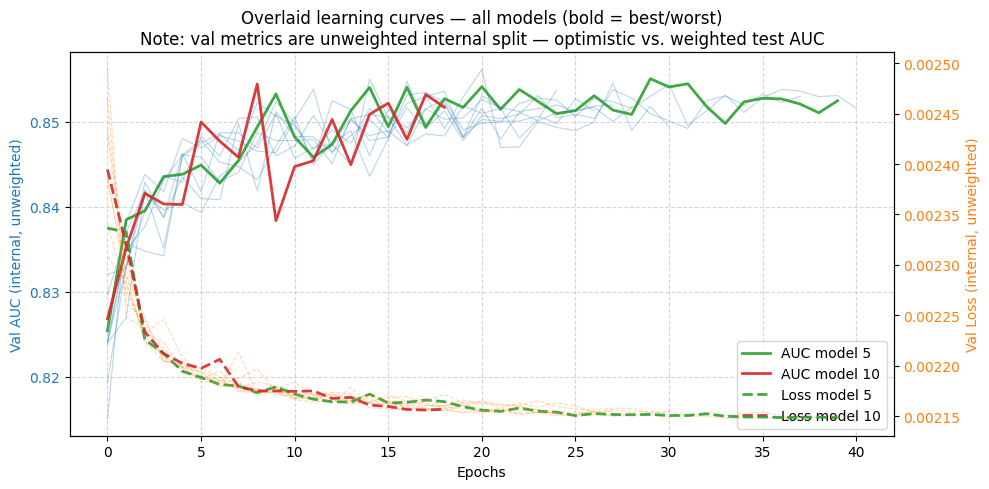

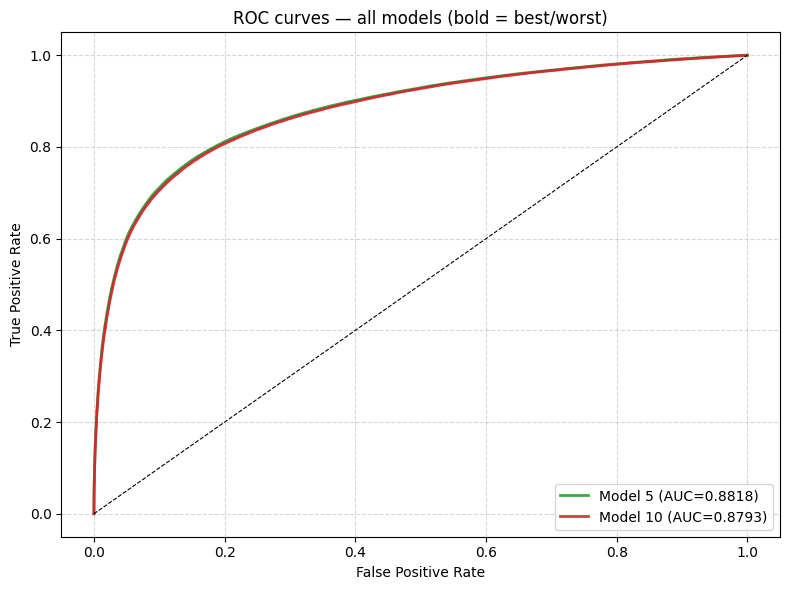

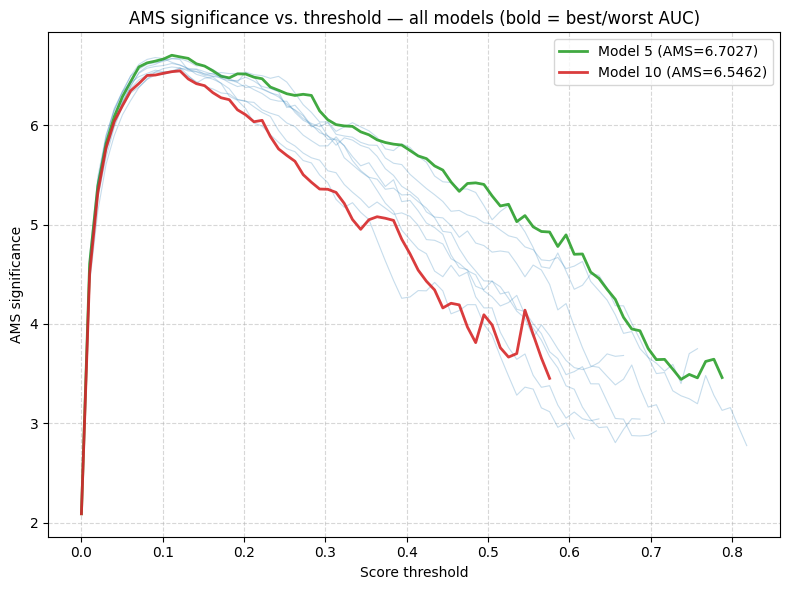

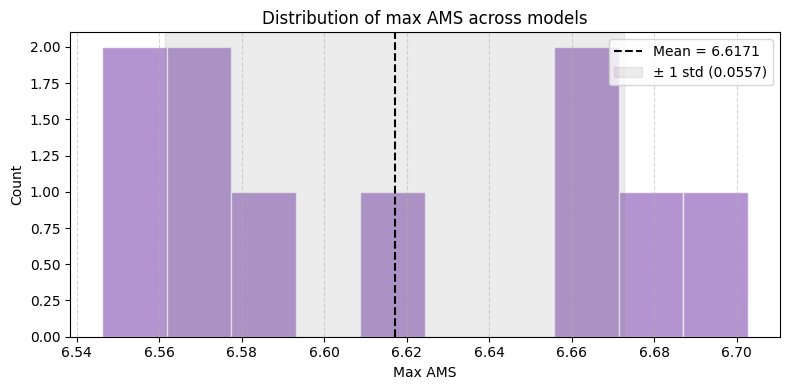

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

N_MOD = 10

models        = []
aucs          = []
significances = []

for i in range(N_MOD):
    print(f"\n=== Training model {i + 1}/{N_MOD} ===")
    nn_i = NeuralNetwork(n_features=X_train.shape[1])
    nn_i.fit(X_train, y_train, weights_train=weights_train)

    preds_i = nn_i.predict(X_test, labels=y_test, weights=weights_test)
    auc_i   = roc_auc_score(y_test, preds_i, sample_weight=weights_test)
    sig_i   = nn_i.significance()

    aucs.append(auc_i)
    significances.append(sig_i)
    models.append(nn_i)
    print(f"Model {i + 1}: AUC = {auc_i:.4f}  |  Max AMS = {sig_i:.4f}")

aucs          = np.array(aucs)
significances = np.array(significances)

# --- Summary statistics ---
print("\n=== Summary over all models ===")
print(f"AUC   — mean: {aucs.mean():.4f}  std: {aucs.std():.4f}  min: {aucs.min():.4f}  max: {aucs.max():.4f}")
print(f"AMS   — mean: {significances.mean():.4f}  std: {significances.std():.4f}  min: {significances.min():.4f}  max: {significances.max():.4f}")

best_idx  = int(np.argmax(aucs))
worst_idx = int(np.argmin(aucs))
print(f"\nBest  model by AUC: model {best_idx + 1}  (AUC = {aucs[best_idx]:.4f})")
print(f"Worst model by AUC: model {worst_idx + 1}  (AUC = {aucs[worst_idx]:.4f})")

# --- AUC bar chart — zoomed y-axis so small differences are visible ---
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, N_MOD + 1), aucs, color="tab:blue", alpha=0.7)
mean_auc, std_auc = aucs.mean(), aucs.std()
ax.axhline(mean_auc, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {mean_auc:.4f}")
ax.axhspan(mean_auc - std_auc, mean_auc + std_auc, color="gray", alpha=0.15, label=f"± 1 std ({std_auc:.4f})")
bars[best_idx].set_color("tab:green")
bars[worst_idx].set_color("tab:red")
ax.set_xlabel("Model index")
ax.set_ylabel("AUC")
ax.set_title("AUC per model (green = best, red = worst)")
ax.set_xticks(range(1, N_MOD + 1))
# Zoom y-axis: show only the meaningful range of variation
margin = max(std_auc * 4, 0.005)
ax.set_ylim(max(0, mean_auc - margin), min(1, mean_auc + margin))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Overlaid learning curves (internal val, unweighted — labelled as such) ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
for i, nn_i in enumerate(models):
    h = nn_i.history.history
    alpha = 0.9 if i in (best_idx, worst_idx) else 0.3
    lw    = 2   if i in (best_idx, worst_idx) else 0.8
    color_auc  = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:blue")
    color_loss = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:orange")
    label_auc  = f"AUC model {i+1}"  if i in (best_idx, worst_idx) else None
    label_loss = f"Loss model {i+1}" if i in (best_idx, worst_idx) else None
    ax1.plot(h.get("val_auc",  h["auc"]),  color=color_auc,  alpha=alpha, linewidth=lw, label=label_auc)
    ax2.plot(h.get("val_loss", h["loss"]), color=color_loss, alpha=alpha, linewidth=lw, linestyle="--", label=label_loss)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Val AUC (internal, unweighted)",  color="tab:blue")
ax2.set_ylabel("Val Loss (internal, unweighted)", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:orange")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
ax1.grid(True, linestyle="--", alpha=0.5)
plt.title("Overlaid learning curves — all models (bold = best/worst)\nNote: val metrics are unweighted internal split — optimistic vs. weighted test AUC")
plt.tight_layout()
plt.show()

# --- Overlaid ROC curves ---
plt.figure(figsize=(8, 6))
for i, nn_i in enumerate(models):
    fpr_i, tpr_i, _ = roc_curve(y_test, nn_i._predictions, sample_weight=weights_test)
    alpha = 0.9 if i in (best_idx, worst_idx) else 0.25
    lw    = 2   if i in (best_idx, worst_idx) else 0.8
    color = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:blue")
    label = f"Model {i+1} (AUC={aucs[i]:.4f})" if i in (best_idx, worst_idx) else None
    plt.plot(fpr_i, tpr_i, color=color, alpha=alpha, linewidth=lw, label=label)
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all models (bold = best/worst)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Overlaid significance curves (b >= 1 guard applied) ---
plt.figure(figsize=(8, 6))
thresholds = np.linspace(0, 1.0, 100)
for i, nn_i in enumerate(models):
    y_true   = nn_i._test_labels
    y_score  = nn_i._predictions
    sw       = nn_i._test_weights
    bins     = np.linspace(0, 1.0, 101)
    s_hist, _ = np.histogram(y_score[y_true == 1], bins=bins, weights=sw[y_true == 1])
    b_hist, _ = np.histogram(y_score[y_true == 0], bins=bins, weights=sw[y_true == 0])
    s_cumul   = np.cumsum(s_hist[::-1])[::-1]
    b_cumul   = np.cumsum(b_hist[::-1])[::-1]
    valid     = (b_cumul >= 1.0) & (s_cumul >= 0)
    safe_b    = np.where(valid, b_cumul, 1.0)
    safe_s    = np.where(valid, s_cumul, 0.0)
    ams_curve = np.where(
        valid,
        np.sqrt(2 * ((safe_s + safe_b) * np.log(1 + safe_s / safe_b) - safe_s)),
        np.nan
    )
    alpha = 0.9 if i in (best_idx, worst_idx) else 0.25
    lw    = 2   if i in (best_idx, worst_idx) else 0.8
    color = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:blue")
    label = f"Model {i+1} (AMS={significances[i]:.4f})" if i in (best_idx, worst_idx) else None
    plt.plot(thresholds, ams_curve, color=color, alpha=alpha, linewidth=lw, label=label)
plt.xlabel("Score threshold")
plt.ylabel("AMS significance")
plt.title("AMS significance vs. threshold — all models (bold = best/worst AUC)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- AMS distribution ---
plt.figure(figsize=(8, 4))
plt.hist(significances, bins=min(N_MOD, 10), color="tab:purple", alpha=0.7, edgecolor="white")
mean_sig, std_sig = significances.mean(), significances.std()
plt.axvline(mean_sig, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {mean_sig:.4f}")
plt.axvspan(mean_sig - std_sig, mean_sig + std_sig, color="gray", alpha=0.15, label=f"± 1 std ({std_sig:.4f})")
plt.xlabel("Max AMS")
plt.ylabel("Count")
plt.title("Distribution of max AMS across models")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Save and Load Models

**Single model** (e.g. the one trained in the first section): call `nn.save_model(path)`.

**Ensemble**: each model is saved to its own subdirectory `models/model_i/`. To reload the full ensemble later, re-run the loop below.

To save only the best model from the ensemble: `models[best_idx].save_model("models/best")`.

In [7]:
# --- Save single model (from the first training section) ---
nn.save_model("models/single")

# To reload it:
# nn_loaded = NeuralNetwork()
# nn_loaded.load_model("models/single")

# --- Save all ensemble models ---
for i, nn_i in enumerate(models):
    nn_i.save_model(f"models/ensemble/model_{i+1}")
print(f"Saved {len(models)} ensemble models.")

# --- Save only the best model ---
models[best_idx].save_model("models/best")
print(f"Best model (model {best_idx + 1}, AUC={aucs[best_idx]:.4f}) saved to models/best.")

# --- Reload the full ensemble ---
# models_loaded = []
# for i in range(N_MOD):
#     nn_i = NeuralNetwork()
#     nn_i.load_model(f"models/ensemble/model_{i+1}")
#     models_loaded.append(nn_i)

Model saved to models/single
Model saved to models/ensemble/model_1
Model saved to models/ensemble/model_2
Model saved to models/ensemble/model_3
Model saved to models/ensemble/model_4
Model saved to models/ensemble/model_5
Model saved to models/ensemble/model_6
Model saved to models/ensemble/model_7
Model saved to models/ensemble/model_8
Model saved to models/ensemble/model_9
Model saved to models/ensemble/model_10
Saved 10 ensemble models.
Model saved to models/best
Best model (model 5, AUC=0.8818) saved to models/best.


### Download Models to Google Drive
Zip any saved model folder and copy it to Google Drive so you can download it from drive.google.com.

In [8]:
import shutil
from google.colab import drive

# Mount Google Drive (will ask for authorisation once)
drive.mount("/content/drive")

# Zip whichever model you want to download, then copy to Drive.
# Change the paths below as needed.

# --- Best model ---
shutil.make_archive("best_model", "zip", "models/best")
shutil.copy("best_model.zip", "/content/drive/MyDrive/best_model.zip")
print("best_model.zip saved to Google Drive")

# --- Full ensemble (optional) ---
# shutil.make_archive("ensemble", "zip", "models/ensemble")
# shutil.copy("ensemble.zip", "/content/drive/MyDrive/ensemble.zip")
# print("ensemble.zip saved to Google Drive")

print("\nGo to drive.google.com to download the zip file(s).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
best_model.zip saved to Google Drive

Go to drive.google.com to download the zip file(s).
